In [22]:
import os, re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

In [23]:
ASM_DIR = "/home/leobrasileo/Desktop/UBA/Tesis/TVM-RVV_optimized_operators/operators/softmax/output"

In [24]:
files = {
    "Fast Vector": "fast/softmax_vector.asm",
    "Classic Vector": "classic/softmax_vector.asm",
    "Classic Scalar": "classic/softmax_scalar.asm",
    "Fast Scalar": "fast/softmax_scalar.asm"
}

tags = {
    "Fast Vector": "main_compute_",
    "Classic Vector": "softmax_compute_",
    "Classic Scalar": "softmax_compute_",
    "Fast Scalar": "main_compute_",
}

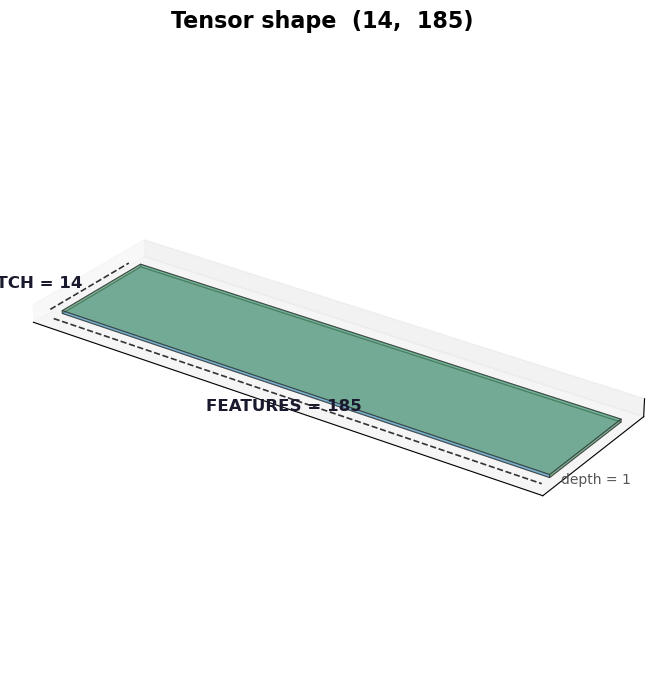

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

BATCH    = 14
FEATURES = 185

def draw_3d_tensor(batch, features, depth=1):
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection='3d')

    # 8 corners of the box
    x = [0, features, features, 0, 0, features, features, 0]
    y = [0, 0, batch,   batch, 0, 0,   batch,   batch]
    z = [0, 0, 0,       0,     depth, depth, depth, depth]

    # 6 faces
    faces = [
        [[x[0],y[0],z[0]], [x[1],y[1],z[1]], [x[2],y[2],z[2]], [x[3],y[3],z[3]]],  # bottom
        [[x[4],y[4],z[4]], [x[5],y[5],z[5]], [x[6],y[6],z[6]], [x[7],y[7],z[7]]],  # top
        [[x[0],y[0],z[0]], [x[1],y[1],z[1]], [x[5],y[5],z[5]], [x[4],y[4],z[4]]],  # front
        [[x[3],y[3],z[3]], [x[2],y[2],z[2]], [x[6],y[6],z[6]], [x[7],y[7],z[7]]],  # back
        [[x[0],y[0],z[0]], [x[3],y[3],z[3]], [x[7],y[7],z[7]], [x[4],y[4],z[4]]],  # left
        [[x[1],y[1],z[1]], [x[2],y[2],z[2]], [x[6],y[6],z[6]], [x[5],y[5],z[5]]],  # right
    ]

    face_colors = [
        '#4C72B0',  # bottom
        '#55A868',  # top
        '#64B5CD',  # front
        '#4393C3',  # back
        '#8DA0CB',  # left
        '#74C476',  # right
    ]

    poly = Poly3DCollection(faces, alpha=0.55, linewidths=0.8, edgecolor='#222222')
    poly.set_facecolor(face_colors)
    ax.add_collection3d(poly)

    # Axis labels with arrows via annotate
    mid_f = features / 2
    mid_b = batch / 2

    ax.text(mid_f, -2, 0,    f'FEATURES = {features}', ha='center', va='top',    fontsize=12, color='#1a1a2e', fontweight='bold')
    ax.text(-8,  mid_b, 0,   f'BATCH = {batch}',       ha='right',  va='center', fontsize=12, color='#1a1a2e', fontweight='bold')
    ax.text(features + 4, 0, depth / 2, 'depth = 1',   ha='left',   va='center', fontsize=10, color='#555')

    # Dimension lines
    ax.plot([0, features], [-1.5, -1.5], [0, 0], color='#333', lw=1.2, linestyle='--')
    ax.plot([-5, -5], [0, batch],        [0, 0], color='#333', lw=1.2, linestyle='--')

    ax.set_xlim(0, features)
    ax.set_ylim(-3, batch + 2)
    ax.set_zlim(0, depth * 6)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_title(f'Tensor shape  ({batch},  {features})', fontsize=16, fontweight='bold', pad=20)

    ax.view_init(elev=28, azim=-55)
    ax.set_box_aspect([features, batch * 4, depth * 6])

    plt.tight_layout()
    plt.show()

draw_3d_tensor(BATCH, FEATURES)

In [26]:
def extract_function_asm(file_path, tag):
    with open(file_path, "r") as f:
        lines = f.readlines()

    extracted = []
    inside = False
    func_header_pattern = re.compile(r"^[0-9a-f]+ <.*>:")
    instr_pattern = re.compile(r"^\s*[0-9a-f]+:\s+(?:[0-9a-f]{2} )+\s*(.+)$")
    tag_header_pattern = re.compile(rf"^[0-9a-f]+ <{re.escape(tag)}>:")

    for line in lines:
        stripped = line.strip()

        if not inside and tag_header_pattern.match(stripped):
            inside = True
            continue

        if inside:
            if func_header_pattern.match(stripped) and not tag_header_pattern.match(stripped):
                break
            m = instr_pattern.match(line)
            if m:
                extracted.append(m.group(1).strip().replace('\t', ' '))

    return extracted


asm_codes = {}
for name, rel_path in files.items():
    full_path = os.path.join(ASM_DIR, rel_path)
    tag = tags[name]
    asm_codes[name] = extract_function_asm(full_path, tag)

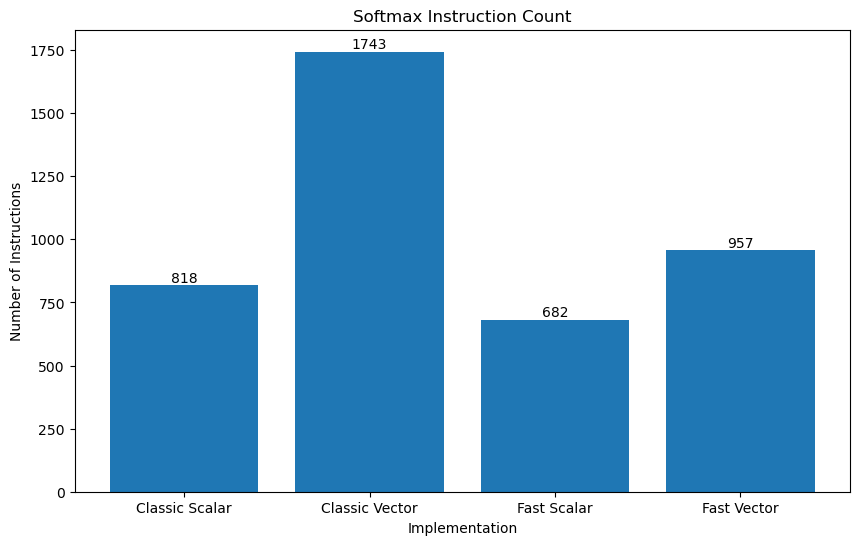

In [27]:
instruction_counts = {}

for name, asm_lines in asm_codes.items():
    instruction_counts[name] = len(asm_lines)


ordered_names = ["Classic Scalar", "Classic Vector", "Fast Scalar", "Fast Vector"]
counts = [instruction_counts[name] for name in ordered_names]


plt.figure(figsize=(10, 6))
bars = plt.bar(ordered_names, counts)

plt.xlabel("Implementation")
plt.ylabel("Number of Instructions")
plt.title("Softmax Instruction Count")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.show()

In [28]:
def classify_instructions(asm_lines):
    scalar = sum(1 for line in asm_lines if not line.lstrip().split()[0].startswith('v'))
    vector = sum(1 for line in asm_lines if line.lstrip().split()[0].startswith('v'))
    return scalar, vector

In [29]:
vector_names = ["Classic Vector", "Fast Vector"]

scalar_counts = []
vector_counts = []
labels = []

for name in vector_names:
    scalar, vector = classify_instructions(asm_codes[name])
    scalar_counts.append(scalar)
    vector_counts.append(vector)
    labels.append(name)

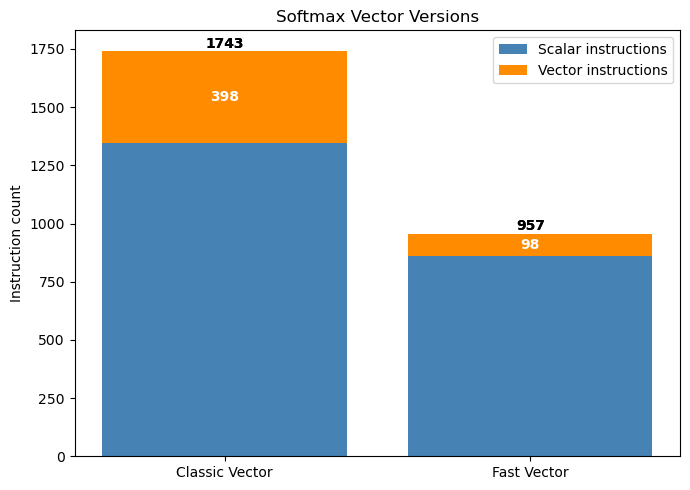

In [30]:
x = range(len(labels))

fig, ax = plt.subplots(figsize=(7, 5))
bars_scalar = ax.bar(x, scalar_counts, color='steelblue', label='Scalar instructions')
bars_vector = ax.bar(x, vector_counts, bottom=scalar_counts, color='darkorange', label='Vector instructions')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Instruction count')
ax.set_title('Softmax Vector Versions')
ax.legend()

for i, (s, v) in enumerate(zip(scalar_counts, vector_counts)):
    ax.text(i, s + v + 0.5, str(s + v), ha='center', va='bottom', fontweight='bold')

for i, (s, v) in enumerate(zip(scalar_counts, vector_counts)):
    ax.text(i, s + v + 0.5, str(s + v), ha='center', va='bottom', fontweight='bold')
    ax.text(i, s + v / 2, str(v), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

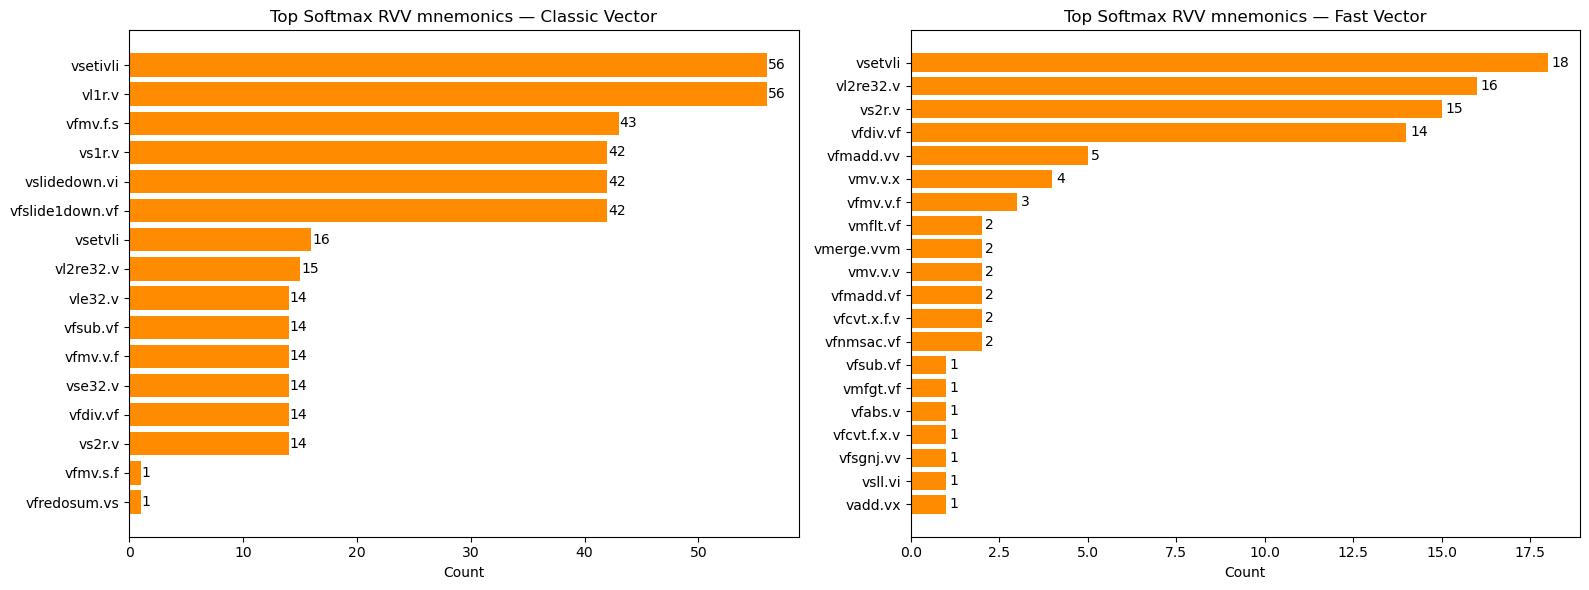

In [31]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, vector_names):
    rvv_mnemonics = [
        line.lstrip().split()[0]
        for line in asm_codes[name]
        if line.lstrip().split()[0].startswith('v')
    ]
    top20 = Counter(rvv_mnemonics).most_common(20)
    mnemonics, counts = zip(*top20)

    ax.barh(mnemonics[::-1], counts[::-1], color='darkorange')
    ax.set_title(f'Top Softmax RVV mnemonics — {name}')
    ax.set_xlabel('Count')
    for i, (m, c) in enumerate(zip(mnemonics[::-1], counts[::-1])):
        ax.text(c + 0.1, i, str(c), va='center')

plt.tight_layout()
plt.show()